# Notebook 09: Pooled Global Model

## Objective

This notebook trains one global model across all five stocks:

- BRK-B
- CVX
- GE
- MSFT
- NVDA

The pooled models use the same feature set and fixed temporal split as Notebook 08:

- **Training:** 2020–2024
- **Testing:** 2025

The purpose is to determine whether a single model trained across multiple companies can learn a common stock-movement pattern.

The pooled model is evaluated separately on each stock in the 2025 test period so that its behaviour can later be compared with the stock-specific models from Notebook 08.

**Models:** Dummy Classifier, Random Forest, XGBoost, L2 Logistic Regression, and a supplementary 30-day-lookback LSTM.

## Research Role

Notebook 08 established stock-specific baselines.

Notebook 09 now evaluates the **pooled/global modelling scenario**:

> Can one model trained on all five stocks perform consistently across the individual stocks?

The same temporal boundary is retained to avoid future information entering the training data. Random train-test splitting is not used.

## Experimental Design

```text
BRK-B ─┐
CVX   ─┤
GE    ─┤──→ One pooled/global model ──→ 2025 predictions
MSFT  ─┤
NVDA  ─┘
```

For the classical models, all 2020–2024 observations are combined into one training set.

The 2025 observations remain separated by ticker during evaluation so that pooled-model performance can be inspected stock by stock.

The `ticker` column is excluded from the predictors. This keeps the feature space consistent with Notebook 08 and prevents the pooled model from simply learning a stock identifier.

In [1]:
# ==========================================================
# Imports
# ==========================================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report
)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42
TEST_YEAR = 2025

print("Imports completed.")

Imports completed.


## Load Model-Ready Dataset

The same model-ready dataset used in Notebook 08 is loaded so that the pooled experiment remains directly comparable.

In [2]:
# ==========================================================
# Load Model-Ready Dataset
# ==========================================================

data_df = pd.read_csv(
    "/kaggle/input/notebooks/phyothaw/06-target-and-model-dataset-ipynb/model_ready_complete_case_2020_2025.csv"
)

data_df["date"] = pd.to_datetime(data_df["date"])

print(f"Dataset shape: {data_df.shape}")

print("\nDate Range")
print(f"Start Date : {data_df['date'].min()}")
print(f"End Date   : {data_df['date'].max()}")

print("\nObservations by Stock")
display(
    data_df["ticker"]
    .value_counts()
    .sort_index()
    .to_frame("Observations")
)

Dataset shape: (7370, 42)

Date Range
Start Date : 2020-01-13 00:00:00
End Date   : 2025-12-22 00:00:00

Observations by Stock


,Observations
ticker,
BRK-B,1474
CVX,1474
GE,1474
MSFT,1474
NVDA,1474


## Handle GDELT Tone Missing Values

The missing-tone indicator is retained so that missing GDELT information remains distinguishable from an observed neutral tone. The tone value itself is filled with zero.

In [3]:
# ==========================================================
# Handle Missing GDELT Tone
# ==========================================================

data_df["gdelt_tone_missing"] = (
    data_df["gdelt_company_tone"].isna().astype(int)
)

data_df["gdelt_company_tone"] = (
    data_df["gdelt_company_tone"].fillna(0)
)

missing = (
    data_df.isna()
    .sum()
    .sort_values(ascending=False)
)

print("Remaining missing values:")
display(
    missing[missing > 0].to_frame("Missing Count")
)

Remaining missing values:


,Missing Count


## Feature Selection

The same predictor definition as Notebook 08 is used. Identifiers, future information, target variables, and low-information dividend/split columns are excluded.

In [4]:
# ==========================================================
# Feature Selection
# ==========================================================

TARGET = "target_5d"

DROP_COLUMNS = [
    # Identifiers
    "ticker",
    "date",

    # Future information / data leakage
    "future_close_5d",
    "forward_return_5d",

    # Target variables
    "movement_5d",
    "target_5d",

    # Low-information / non-predictive columns
    "Dividends",
    "Stock Splits",

    # Diagnostic/check column — not a modelling feature
    "daily_return_check"
]

FEATURE_COLUMNS = [
    column
    for column in data_df.columns
    if column not in DROP_COLUMNS
]

print("=" * 60)
print("Feature Selection")
print("=" * 60)

print(f"Total Columns      : {data_df.shape[1]}")
print(f"Dropped Columns    : {len(DROP_COLUMNS)}")
print(f"Predictor Features : {len(FEATURE_COLUMNS)}")

print("\nPredictor Features")
print(FEATURE_COLUMNS)

print("\nDiagnostic column excluded:")
print("daily_return_check")


Feature Selection
Total Columns      : 42
Dropped Columns    : 9
Predictor Features : 33

Predictor Features
['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_50', 'SMA_200', 'EMA_50', 'EMA_200', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'ATR', 'ADX', 'gdelt_company_tone', 'gdelt_tone_missing', 'gdelt_tone_lag_1', 'gdelt_tone_mean_3', 'gdelt_tone_mean_5', 'gdelt_tone_std_5', 'gdelt_tone_change_1d', 'gdelt_abnormal_tone_20', 'market_close', 'market_return', 'vix_close', 'vix_change', 'market_return_lag_1', 'vix_close_lag_1', 'vix_change_lag_1']

Diagnostic column excluded:
daily_return_check


## Temporal Train-Test Split

All stocks use the same fixed temporal boundary:

- **Training:** 2020–2024
- **Testing:** 2025

The pooled training set contains observations from all five stocks. The 2025 test set is retained with ticker information for stock-level evaluation.

In [5]:
# ==========================================================
# Prepare Pooled Train/Test Data
# ==========================================================

train_df = (
    data_df[
        data_df["date"].dt.year < TEST_YEAR
    ]
    .sort_values(["ticker", "date"])
    .copy()
)

test_df = (
    data_df[
        data_df["date"].dt.year == TEST_YEAR
    ]
    .sort_values(["ticker", "date"])
    .copy()
)

x_train = train_df[FEATURE_COLUMNS]
y_train = train_df[TARGET]

x_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET]

print("=" * 60)
print("Pooled Temporal Split")
print("=" * 60)

print(f"Training samples : {len(train_df):,}")
print(f"Testing samples  : {len(test_df):,}")
print(f"Features         : {len(FEATURE_COLUMNS)}")

print("\nTraining observations by stock")
display(
    train_df["ticker"]
    .value_counts()
    .sort_index()
    .to_frame("Training Samples")
)

print("\nTesting observations by stock")
display(
    test_df["ticker"]
    .value_counts()
    .sort_index()
    .to_frame("Testing Samples")
)

Pooled Temporal Split
Training samples : 6,240
Testing samples  : 1,130
Features         : 33

Training observations by stock


,Training Samples
ticker,
BRK-B,1248
CVX,1248
GE,1248
MSFT,1248
NVDA,1248



Testing observations by stock


,Testing Samples
ticker,
BRK-B,226
CVX,226
GE,226
MSFT,226
NVDA,226


## Initialise Results Containers

The performance table stores one row per model and stock. The prediction table stores the 2025 predicted class and class probabilities so that Notebook 12 can later perform calibration and reliability analysis.

In [6]:
# ==========================================================
# Initialise Results Containers
# ==========================================================

all_results = []
all_predictions = []

stocks = sorted(data_df["ticker"].unique())

print(f"Stocks: {stocks}")
print("Results containers initialized.")

Stocks: ['BRK-B', 'CVX', 'GE', 'MSFT', 'NVDA']
Results containers initialized.


## Model 1 — Dummy Classifier

The Dummy Classifier provides a pooled majority-class baseline. It is trained once using the combined training data and evaluated separately for each stock.

In [7]:
# ==========================================================
# Dummy Classifier
# ==========================================================

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(x_train, y_train)

dummy_pred_all = dummy_model.predict(x_test)
dummy_prob_all = dummy_model.predict_proba(x_test)

for stock in stocks:

    mask = test_df["ticker"].values == stock

    stock_y = y_test.iloc[mask]
    stock_pred = dummy_pred_all[mask]
    stock_prob = dummy_prob_all[mask]
    stock_dates = test_df.loc[mask, "date"].values

    accuracy = accuracy_score(stock_y, stock_pred)
    balanced_accuracy = balanced_accuracy_score(stock_y, stock_pred)
    precision = precision_score(
        stock_y, stock_pred,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        stock_y, stock_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        stock_y, stock_pred,
        average="weighted",
        zero_division=0
    )
    roc_auc = roc_auc_score(
        stock_y,
        stock_prob,
        multi_class="ovr",
        labels=[0, 1, 2]
    )

    all_results.append({
        "ticker": stock,
        "model": "Dummy Classifier",
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
        "roc_auc_ovr": roc_auc
    })

    all_predictions.append(
        pd.DataFrame({
            "ticker": stock,
            "date": stock_dates,
            "model": "Dummy Classifier",
            "actual": stock_y.values,
            "predicted": stock_pred,
            "prob_down": stock_prob[:, 0],
            "prob_neutral": stock_prob[:, 1],
            "prob_up": stock_prob[:, 2]
        })
    )

print("Dummy pooled model completed.")

Dummy pooled model completed.


## Model 2 — Random Forest

Random Forest is trained once on the pooled 2020–2024 data. Because tree-based models do not require standardization, the original feature scale is retained.

In [8]:
# ==========================================================
# Random Forest
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(x_train, y_train)

rf_pred_all = rf_model.predict(x_test)
rf_prob_all = rf_model.predict_proba(x_test)

for stock in stocks:

    mask = test_df["ticker"].values == stock

    stock_y = y_test.iloc[mask]
    stock_pred = rf_pred_all[mask]
    stock_prob = rf_prob_all[mask]
    stock_dates = test_df.loc[mask, "date"].values

    accuracy = accuracy_score(stock_y, stock_pred)
    balanced_accuracy = balanced_accuracy_score(stock_y, stock_pred)
    precision = precision_score(
        stock_y, stock_pred,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        stock_y, stock_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        stock_y, stock_pred,
        average="weighted",
        zero_division=0
    )
    roc_auc = roc_auc_score(
        stock_y,
        stock_prob,
        multi_class="ovr",
        labels=[0, 1, 2]
    )

    all_results.append({
        "ticker": stock,
        "model": "Random Forest",
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
        "roc_auc_ovr": roc_auc
    })

    all_predictions.append(
        pd.DataFrame({
            "ticker": stock,
            "date": stock_dates,
            "model": "Random Forest",
            "actual": stock_y.values,
            "predicted": stock_pred,
            "prob_down": stock_prob[:, 0],
            "prob_neutral": stock_prob[:, 1],
            "prob_up": stock_prob[:, 2]
        })
    )

print("Random Forest pooled model completed.")

Random Forest pooled model completed.


## Model 3 — XGBoost

XGBoost is trained once on the pooled 2020–2024 observations and then evaluated separately on each 2025 stock.

In [9]:
# ==========================================================
# XGBoost
# ==========================================================

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(x_train, y_train)

xgb_pred_all = xgb_model.predict(x_test)
xgb_prob_all = xgb_model.predict_proba(x_test)

for stock in stocks:

    mask = test_df["ticker"].values == stock

    stock_y = y_test.iloc[mask]
    stock_pred = xgb_pred_all[mask]
    stock_prob = xgb_prob_all[mask]
    stock_dates = test_df.loc[mask, "date"].values

    accuracy = accuracy_score(stock_y, stock_pred)
    balanced_accuracy = balanced_accuracy_score(stock_y, stock_pred)
    precision = precision_score(
        stock_y, stock_pred,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        stock_y, stock_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        stock_y, stock_pred,
        average="weighted",
        zero_division=0
    )
    roc_auc = roc_auc_score(
        stock_y,
        stock_prob,
        multi_class="ovr",
        labels=[0, 1, 2]
    )

    all_results.append({
        "ticker": stock,
        "model": "XGBoost",
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
        "roc_auc_ovr": roc_auc
    })

    all_predictions.append(
        pd.DataFrame({
            "ticker": stock,
            "date": stock_dates,
            "model": "XGBoost",
            "actual": stock_y.values,
            "predicted": stock_pred,
            "prob_down": stock_prob[:, 0],
            "prob_neutral": stock_prob[:, 1],
            "prob_up": stock_prob[:, 2]
        })
    )

print("XGBoost pooled model completed.")

XGBoost pooled model completed.


## Model 4 — L2 Logistic Regression

The scaler is fitted only on the pooled training data and then applied to the pooled test data. This prevents test-set information from influencing feature scaling.

In [10]:
# ==========================================================
# Logistic Regression
# ==========================================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

lr_model = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)

lr_model.fit(x_train_scaled, y_train)

lr_pred_all = lr_model.predict(x_test_scaled)
lr_prob_all = lr_model.predict_proba(x_test_scaled)

for stock in stocks:

    mask = test_df["ticker"].values == stock

    stock_y = y_test.iloc[mask]
    stock_pred = lr_pred_all[mask]
    stock_prob = lr_prob_all[mask]
    stock_dates = test_df.loc[mask, "date"].values

    accuracy = accuracy_score(stock_y, stock_pred)
    balanced_accuracy = balanced_accuracy_score(stock_y, stock_pred)
    precision = precision_score(
        stock_y, stock_pred,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        stock_y, stock_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        stock_y, stock_pred,
        average="weighted",
        zero_division=0
    )
    roc_auc = roc_auc_score(
        stock_y,
        stock_prob,
        multi_class="ovr",
        labels=[0, 1, 2]
    )

    all_results.append({
        "ticker": stock,
        "model": "Logistic Regression",
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
        "roc_auc_ovr": roc_auc
    })

    all_predictions.append(
        pd.DataFrame({
            "ticker": stock,
            "date": stock_dates,
            "model": "Logistic Regression",
            "actual": stock_y.values,
            "predicted": stock_pred,
            "prob_down": stock_prob[:, 0],
            "prob_neutral": stock_prob[:, 1],
            "prob_up": stock_prob[:, 2]
        })
    )

print("Logistic Regression pooled model completed.")

Logistic Regression pooled model completed.


## Model 5 — LSTM

LSTM is retained as a **supplementary deep-learning baseline**.

A **30-trading-day lookback** is used. Sequences are constructed separately within each stock so that a sequence never crosses from one company into another.

To avoid a generic random validation split, the LSTM uses a temporal validation year:

- **2020–2023 → validation-model training**
- **2024 → temporal validation / early stopping**
- **2025 → final unseen test**

The validation scaler is fitted only on 2020–2023. After selecting the number of epochs from 2024, the final scaler is fitted on all 2020–2024 training observations and the final LSTM is retrained before evaluating the unseen 2025 test period.

In [11]:
# ==========================================================
# Prepare Pooled LSTM Data
# ==========================================================

import tensorflow as tf

tf.keras.utils.set_random_seed(RANDOM_STATE)

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("GPU available:", tf.config.list_physical_devices("GPU"))

LOOKBACK = 30
VALIDATION_YEAR = 2024

# ----------------------------------------------------------
# Helper: create sequences for a target period
# ----------------------------------------------------------

def build_lstm_sequences(
    target_df,
    feature_columns,
    target_column,
    stocks,
    lookback=30,
    context_df=None
):
    """
    Build sequences separately for each stock.

    If context_df is supplied, the final `lookback` observations
    from the same stock in context_df are used before the target
    period. This is required for the first target observation.
    """

    x_sequences = []
    y_values = []
    metadata = []

    for stock in stocks:

        stock_target = (
            target_df[target_df["ticker"] == stock]
            .sort_values("date")
            .reset_index(drop=True)
        )

        if context_df is not None:
            stock_context = (
                context_df[context_df["ticker"] == stock]
                .sort_values("date")
                .tail(lookback)
                .reset_index(drop=True)
            )

            combined = pd.concat(
                [stock_context, stock_target],
                ignore_index=True
            )

            target_start = len(stock_context)

        else:
            combined = stock_target.copy()
            target_start = lookback

        for i in range(target_start, len(combined)):

            if i < lookback:
                continue

            x_sequences.append(
                combined.loc[
                    i - lookback:i - 1,
                    feature_columns
                ].values
            )

            y_values.append(
                combined.loc[i, target_column]
            )

            metadata.append({
                "ticker": stock,
                "date": combined.loc[i, "date"]
            })

    return (
        np.asarray(x_sequences),
        np.asarray(y_values),
        pd.DataFrame(metadata)
    )


# ----------------------------------------------------------
# Temporal validation design
#
# 2020–2023 → validation-model training
# 2024       → validation
# 2025       → final unseen test
# ----------------------------------------------------------

lstm_train_period = (
    data_df[
        data_df["date"].dt.year < VALIDATION_YEAR
    ]
    .sort_values(["ticker", "date"])
    .copy()
)

lstm_validation_period = (
    data_df[
        data_df["date"].dt.year == VALIDATION_YEAR
    ]
    .sort_values(["ticker", "date"])
    .copy()
)

lstm_test_period = (
    data_df[
        data_df["date"].dt.year == TEST_YEAR
    ]
    .sort_values(["ticker", "date"])
    .copy()
)

# ----------------------------------------------------------
# Validation scaler:
# fit ONLY on 2020–2023
# ----------------------------------------------------------

validation_scaler = StandardScaler()

lstm_train_scaled = lstm_train_period.copy()
lstm_validation_scaled = lstm_validation_period.copy()

lstm_train_scaled[FEATURE_COLUMNS] = (
    validation_scaler.fit_transform(
        lstm_train_period[FEATURE_COLUMNS]
    )
)

lstm_validation_scaled[FEATURE_COLUMNS] = (
    validation_scaler.transform(
        lstm_validation_period[FEATURE_COLUMNS]
    )
)

# ----------------------------------------------------------
# Build 2020–2023 training sequences
# ----------------------------------------------------------

x_lstm_train, y_lstm_train, _ = build_lstm_sequences(
    target_df=lstm_train_scaled,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET,
    stocks=stocks,
    lookback=LOOKBACK
)

# ----------------------------------------------------------
# Build 2024 validation sequences.
# The final 30 observations from 2020–2023 of the SAME stock
# provide context for the first 2024 observation.
# ----------------------------------------------------------

x_lstm_val, y_lstm_val, validation_sequence_meta = (
    build_lstm_sequences(
        target_df=lstm_validation_scaled,
        feature_columns=FEATURE_COLUMNS,
        target_column=TARGET,
        stocks=stocks,
        lookback=LOOKBACK,
        context_df=lstm_train_scaled
    )
)

print("LSTM training sequence shape   :", x_lstm_train.shape)
print("LSTM validation sequence shape :", x_lstm_val.shape)
print("Validation observations by stock:")
display(
    validation_sequence_meta["ticker"]
    .value_counts()
    .sort_index()
    .to_frame("Validation Sequences")
)


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
LSTM training sequence shape   : (4830, 30, 33)
LSTM validation sequence shape : (1260, 30, 33)
Validation observations by stock:


,Validation Sequences
ticker,
BRK-B,252
CVX,252
GE,252
MSFT,252
NVDA,252


In [12]:
# ==========================================================
# Build and Validate Pooled LSTM
# ==========================================================

def create_lstm_model(input_shape):

    model = Sequential([
        Input(shape=input_shape),

        LSTM(64),

        Dropout(0.2),

        Dense(32, activation="relu"),

        Dense(3, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


validation_lstm = create_lstm_model(
    (
        x_lstm_train.shape[1],
        x_lstm_train.shape[2]
    )
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

validation_history = validation_lstm.fit(
    x_lstm_train,
    y_lstm_train,
    epochs=50,
    batch_size=32,
    validation_data=(
        x_lstm_val,
        y_lstm_val
    ),
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

best_epoch = (
    np.argmin(
        validation_history.history["val_loss"]
    ) + 1
)

print(f"Best validation epoch: {best_epoch}")
print(
    f"Best validation loss: "
    f"{min(validation_history.history['val_loss']):.4f}"
)


I0000 00:00:1786289812.576492      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786289812.579302      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3905 - loss: 1.0950 - val_accuracy: 0.3810 - val_loss: 1.0986
Epoch 2/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4472 - loss: 1.0601 - val_accuracy: 0.3706 - val_loss: 1.0957
Epoch 3/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4451 - loss: 1.0528 - val_accuracy: 0.3929 - val_loss: 1.0869
Epoch 4/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4586 - loss: 1.0426 - val_accuracy: 0.4222 - val_loss: 1.0811
Epoch 5/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4638 - loss: 1.0308 - val_accuracy: 0.3944 - val_loss: 1.0980
Epoch 6/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4807 - loss: 1.0192 - val_accuracy: 0.3690 - val_loss: 1.0959
Epoch 7/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4952 - loss: 1.0086 - val_accuracy: 0.3778 - val_loss: 1.1157
Epoch 8/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4930 - loss: 1.0015 - val_accuracy: 0.

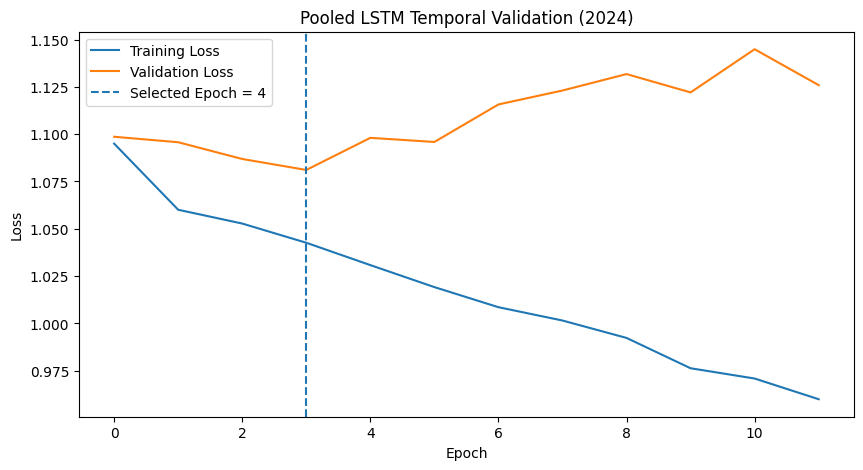

In [13]:
# ==========================================================
# LSTM Validation History
# ==========================================================

plt.figure(figsize=(10, 5))

plt.plot(
    validation_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    validation_history.history["val_loss"],
    label="Validation Loss"
)

plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label=f"Selected Epoch = {best_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Pooled LSTM Temporal Validation (2024)")
plt.legend()
plt.show()


In [14]:
# ==========================================================
# Retrain Final Pooled LSTM on 2020–2024
# ==========================================================

# ----------------------------------------------------------
# Fit the final scaler on ALL training observations
# (2020–2024 only)
# ----------------------------------------------------------

final_lstm_scaler = StandardScaler()

final_train_scaled = train_df.copy()
final_test_scaled = test_df.copy()

final_train_scaled[FEATURE_COLUMNS] = (
    final_lstm_scaler.fit_transform(
        train_df[FEATURE_COLUMNS]
    )
)

final_test_scaled[FEATURE_COLUMNS] = (
    final_lstm_scaler.transform(
        test_df[FEATURE_COLUMNS]
    )
)

# ----------------------------------------------------------
# Final training sequences: all 2020–2024
# ----------------------------------------------------------

x_final_train, y_final_train, _ = build_lstm_sequences(
    target_df=final_train_scaled,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET,
    stocks=stocks,
    lookback=LOOKBACK
)

# ----------------------------------------------------------
# Final test sequences: 2025
# The final 30 training observations of the SAME stock
# provide context for the first 2025 observation.
# ----------------------------------------------------------

x_final_test, y_final_test, test_sequence_meta = (
    build_lstm_sequences(
        target_df=final_test_scaled,
        feature_columns=FEATURE_COLUMNS,
        target_column=TARGET,
        stocks=stocks,
        lookback=LOOKBACK,
        context_df=final_train_scaled
    )
)

print(
    "Final training sequence shape:",
    x_final_train.shape
)

print(
    "Final testing sequence shape :",
    x_final_test.shape
)

# ----------------------------------------------------------
# Rebuild final model using the epoch count selected
# from the 2024 temporal validation period.
# ----------------------------------------------------------

lstm_model = create_lstm_model(
    (
        x_final_train.shape[1],
        x_final_train.shape[2]
    )
)

lstm_model.fit(
    x_final_train,
    y_final_train,
    epochs=best_epoch,
    batch_size=32,
    shuffle=False,
    verbose=1
)

# ----------------------------------------------------------
# Final 2025 predictions
# ----------------------------------------------------------

lstm_prob_all = lstm_model.predict(
    x_final_test,
    verbose=0
)

lstm_pred_all = np.argmax(
    lstm_prob_all,
    axis=1
)

for stock in stocks:

    mask = (
        test_sequence_meta["ticker"].values == stock
    )

    stock_y = y_final_test[mask]
    stock_pred = lstm_pred_all[mask]
    stock_prob = lstm_prob_all[mask]

    stock_dates = test_sequence_meta.loc[
        mask, "date"
    ].values

    accuracy = accuracy_score(
        stock_y,
        stock_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        stock_y,
        stock_pred
    )

    precision = precision_score(
        stock_y,
        stock_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        stock_y,
        stock_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        stock_y,
        stock_pred,
        average="weighted",
        zero_division=0
    )

    roc_auc = roc_auc_score(
        stock_y,
        stock_prob,
        multi_class="ovr",
        labels=[0, 1, 2]
    )

    all_results.append({
        "ticker": stock,
        "model": "LSTM",
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
        "roc_auc_ovr": roc_auc
    })

    all_predictions.append(
        pd.DataFrame({
            "ticker": stock,
            "date": stock_dates,
            "model": "LSTM",
            "actual": stock_y,
            "predicted": stock_pred,
            "prob_down": stock_prob[:, 0],
            "prob_neutral": stock_prob[:, 1],
            "prob_up": stock_prob[:, 2]
        })
    )

print("Final pooled LSTM evaluation completed.")


Final training sequence shape: (6090, 30, 33)
Final testing sequence shape : (1130, 30, 33)
Epoch 1/4
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4034 - loss: 1.0846
Epoch 2/4
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4389 - loss: 1.0663
Epoch 3/4
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4501 - loss: 1.0523
Epoch 4/4
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4624 - loss: 1.0449
Final pooled LSTM evaluation completed.


## Methodological Checks Before Freezing Notebook 09

The pooled experiment is now based on:

- **33 predictive features** after removing the diagnostic `daily_return_check` column.
- A fixed **2020–2024 training period** and **2025 unseen test period**.
- No random train-test split.
- `ticker` excluded from the predictor matrix.
- LSTM temporal validation using **2020–2023 for validation-model training and 2024 for validation**.
- Validation scaling fitted only on 2020–2023.
- Final LSTM retrained on all 2020–2024 data using the epoch count selected from 2024.

These choices keep the pooled experiment aligned with the project's temporal and leakage-prevention requirements.

## Pooled Model Performance

There should be **25 stock-model evaluations**: five pooled models evaluated separately on each of the five stocks.

In [15]:
# ==========================================================
# Pooled Model Performance
# ==========================================================

pooled_results_df = pd.DataFrame(all_results)

print(
    f"Number of model evaluations: "
    f"{len(pooled_results_df)}"
)

if len(pooled_results_df) != 25:
    print(
        "\nWarning: Expected 25 evaluations "
        "(5 stocks × 5 pooled models)."
    )

display(
    pooled_results_df
    .sort_values(
        ["ticker", "balanced_accuracy"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

Number of model evaluations: 25


,ticker,model,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr
0,BRK-B,Random Forest,0.3053,0.3756,0.3838,0.3053,0.2501,0.5503
1,BRK-B,Logistic Regression,0.5000,0.3692,0.3364,0.5000,0.3905,0.5300
2,BRK-B,LSTM,0.3451,0.3598,0.4355,0.3451,0.2848,0.5477
3,BRK-B,Dummy Classifier,0.2788,0.3333,0.0777,0.2788,0.1215,0.5000
4,BRK-B,XGBoost,0.3407,0.3333,0.3814,0.3407,0.3345,0.5370
5,CVX,Dummy Classifier,0.3451,0.3333,0.1191,0.3451,0.1771,0.5000
6,CVX,Random Forest,0.2788,0.3265,0.3647,0.2788,0.2725,0.5333
7,CVX,LSTM,0.3540,0.3245,0.3819,0.3540,0.2921,0.5340
8,CVX,Logistic Regression,0.2920,0.3217,0.3779,0.2920,0.2959,0.4738
9,CVX,XGBoost,0.2699,0.3197,0.3268,0.2699,0.2568,0.4770


In [16]:
# ==========================================================
# Best Pooled Model per Stock
# ==========================================================

best_pooled_per_stock = (
    pooled_results_df
    .sort_values(
        ["ticker", "balanced_accuracy"],
        ascending=[True, False]
    )
    .groupby("ticker", as_index=False)
    .first()
)

display(
    best_pooled_per_stock[
        [
            "ticker",
            "model",
            "accuracy",
            "balanced_accuracy",
            "f1_weighted",
            "roc_auc_ovr"
        ]
    ]
)

,ticker,model,accuracy,balanced_accuracy,f1_weighted,roc_auc_ovr
0,BRK-B,Random Forest,0.3053,0.3756,0.2501,0.5503
1,CVX,Dummy Classifier,0.3451,0.3333,0.1771,0.5000
2,GE,Random Forest,0.4204,0.4272,0.4265,0.5915
3,MSFT,Logistic Regression,0.4159,0.3388,0.3591,0.5345
4,NVDA,Random Forest,0.4336,0.3589,0.3929,0.5892


## Pooled Model Performance by Algorithm

This table aggregates the pooled model across the five test stocks. It is descriptive only; stock-level results remain important because the research is concerned with cross-stock behaviour.

In [17]:
# ==========================================================
# Average Pooled Performance Across Stocks
# ==========================================================

pooled_model_summary = (
    pooled_results_df
    .groupby("model")[
        [
            "accuracy",
            "balanced_accuracy",
            "precision_weighted",
            "recall_weighted",
            "f1_weighted",
            "roc_auc_ovr"
        ]
    ]
    .mean()
    .sort_values(
        "balanced_accuracy",
        ascending=False
    )
    .reset_index()
)

display(
    pooled_model_summary
)

,model,accuracy,balanced_accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr
0,Random Forest,0.3531,0.3642,0.4312,0.3531,0.3353,0.5559
1,Logistic Regression,0.3876,0.3453,0.3656,0.3876,0.3432,0.5359
2,LSTM,0.3876,0.3376,0.3748,0.3876,0.3136,0.5475
3,XGBoost,0.3372,0.3369,0.3750,0.3372,0.3269,0.5172
4,Dummy Classifier,0.3752,0.3333,0.1475,0.3752,0.2098,0.5000


## Pooled Predictions

Predicted probabilities are retained for the later calibration and reliability analysis in Notebook 12.

The prediction file contains:

- ticker
- date
- model
- actual class
- predicted class
- probability of Down
- probability of Neutral
- probability of Up

In [18]:
# ==========================================================
# Combine and Validate Predictions
# ==========================================================

pooled_predictions_df = pd.concat(
    all_predictions,
    ignore_index=True
)

print(
    f"Prediction rows: "
    f"{len(pooled_predictions_df):,}"
)

print("\nProbability columns:")
display(
    pooled_predictions_df[
        [
            "prob_down",
            "prob_neutral",
            "prob_up"
        ]
    ].describe()
)

probability_sum = (
    pooled_predictions_df[
        [
            "prob_down",
            "prob_neutral",
            "prob_up"
        ]
    ]
    .sum(axis=1)
)

print(
    "\nMaximum probability-sum error:",
    np.abs(probability_sum - 1).max()
)

display(
    pooled_predictions_df.head()
)

Prediction rows: 5,650

Probability columns:


,prob_down,prob_neutral,prob_up
count,5650.0000,5650.0000,5650.0000
mean,0.2897,0.2466,0.4637
std,0.1987,0.1607,0.3008
min,0.0000,0.0000,0.0186
25%,0.1667,0.1366,0.2563
50%,0.3052,0.2750,0.3719
75%,0.4037,0.3533,0.5600
max,0.9336,0.8028,1.0000



Maximum probability-sum error: 8.940696716308594e-08


,ticker,date,model,actual,predicted,prob_down,prob_neutral,prob_up
0,BRK-B,2025-01-02,Dummy Classifier,0,2,0.0000,0.0000,1.0000
1,BRK-B,2025-01-03,Dummy Classifier,0,2,0.0000,0.0000,1.0000
2,BRK-B,2025-01-06,Dummy Classifier,1,2,0.0000,0.0000,1.0000
3,BRK-B,2025-01-07,Dummy Classifier,1,2,0.0000,0.0000,1.0000
4,BRK-B,2025-01-08,Dummy Classifier,2,2,0.0000,0.0000,1.0000


In [19]:
# ==========================================================
# Save Pooled Model Results
# ==========================================================

pooled_results_df.to_csv(
    "/kaggle/working/pooled_model_performance.csv",
    index=False
)

pooled_predictions_df.to_csv(
    "/kaggle/working/pooled_model_predictions.csv",
    index=False
)

print("Saved:")
print("/kaggle/working/pooled_model_performance.csv")
print("/kaggle/working/pooled_model_predictions.csv")

Saved:
/kaggle/working/pooled_model_performance.csv
/kaggle/working/pooled_model_predictions.csv


## Notebook 09 Conclusion

Notebook 09 evaluates the **pooled/global modelling scenario**.

One model is trained across all five stocks and then evaluated separately on the unseen 2025 observations for each stock.

The outputs are:

- `pooled_model_performance.csv`
- `pooled_model_predictions.csv`

These results will be used later for the consolidated comparison with:

- Notebook 08 — stock-specific models
- Notebook 10 — leave-one-stock-out generalisation

Reliability metrics such as calibration, Brier score, Log Loss, ECE, and confidence analysis are intentionally handled later rather than repeated here.

### Key interpretation

Notebook 09 does **not** establish a final "best model". It establishes how a single pooled model behaves across the five companies. Final model comparisons are made after the stock-specific, pooled, and leave-one-stock-out experiments are brought together.
